# DA6401 Assignment 1  
## 2.1 Data Exploration and Class Distribution

In this notebook, we:
- Log 5 sample images from each class using Weights & Biases
- Analyze visual similarities between classes
- Log class distribution statistics

In [21]:
import sys
import os

# Get project root (one level above notebooks/)
project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))

if project_root not in sys.path:
    sys.path.append(project_root)

print("Project root added to path:", project_root)

Project root added to path: /home/muhammed786fiyas/Projects/Deep Learning/Assignment-1/da6401-assignment-1-da25m018


In [22]:
import numpy as np
import matplotlib.pyplot as plt
import wandb

from src.utils.data_loader import load_data

In [23]:
wandb.init(
    project="da6401-assignment-1",
    name="data-exploration-mnist"
)

In [24]:
X_train, y_train, X_test, y_test, _, _ = load_data("mnist")

print("Training samples:", X_train.shape)
print("Test samples:", X_test.shape)

Training samples: (60000, 784)
Test samples: (10000, 784)


In [25]:
table = wandb.Table(columns=["Image", "Label"])

for cls in range(10):
    indices = np.where(y_train == cls)[0][:5]
    
    for idx in indices:
        img = X_train[idx].reshape(28, 28)
        table.add_data(wandb.Image(img), cls)

wandb.log({"Sample Images Per Class": table})

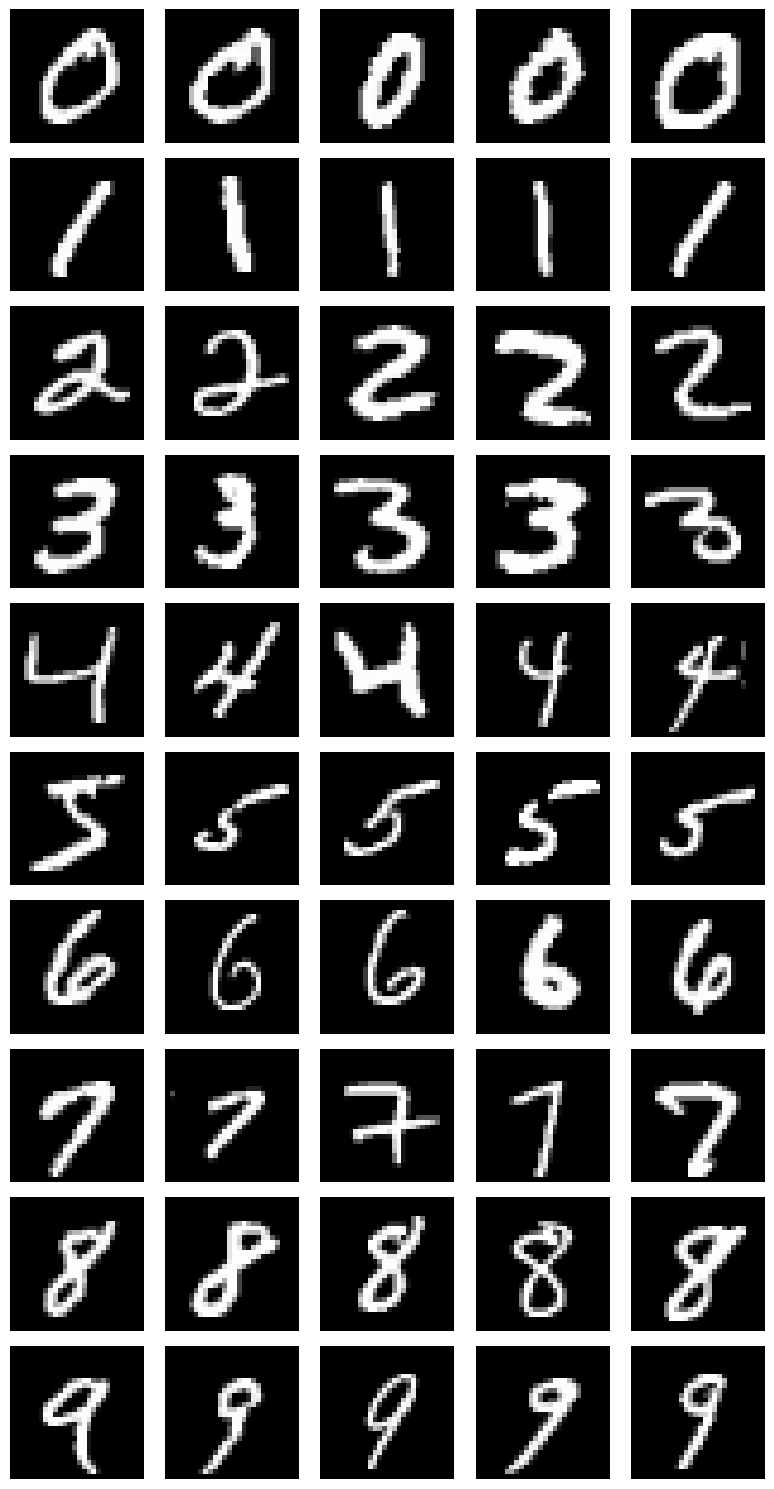

In [26]:
fig, axes = plt.subplots(10, 5, figsize=(8, 15))

for cls in range(10):
    indices = np.where(y_train == cls)[0][:5]
    
    for j, idx in enumerate(indices):
        axes[cls, j].imshow(X_train[idx].reshape(28, 28), cmap="gray")
        axes[cls, j].axis("off")

plt.tight_layout()
plt.show()

In [27]:
unique, counts = np.unique(y_train, return_counts=True)

class_table = wandb.Table(
    data=[[int(u), int(c)] for u, c in zip(unique, counts)],
    columns=["Class", "Count"]
)

wandb.log({"Class Distribution": class_table})

print(dict(zip(unique, counts)))

{np.uint8(0): np.int64(5923), np.uint8(1): np.int64(6742), np.uint8(2): np.int64(5958), np.uint8(3): np.int64(6131), np.uint8(4): np.int64(5842), np.uint8(5): np.int64(5421), np.uint8(6): np.int64(5918), np.uint8(7): np.int64(6265), np.uint8(8): np.int64(5851), np.uint8(9): np.int64(5949)}


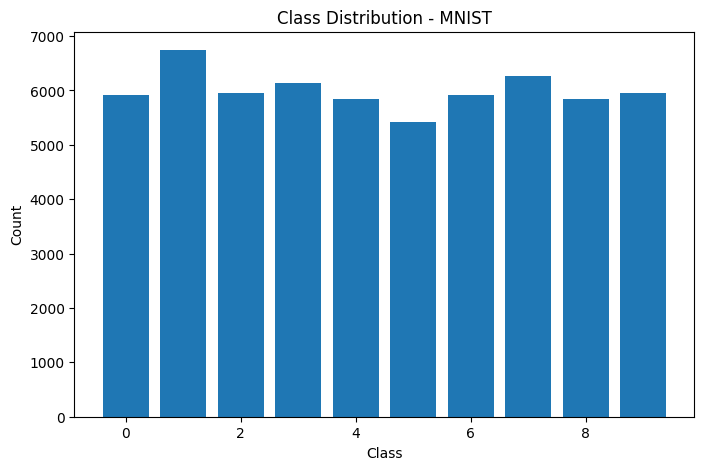

In [28]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8,5))
ax.bar(unique, counts)
ax.set_xlabel("Class")
ax.set_ylabel("Count")
ax.set_title("Class Distribution - MNIST")

wandb.log({"Class Distribution Plot": wandb.Image(fig)})

plt.show()
plt.close(fig)

In [29]:
wandb.finish()